# **EDA**

#Por quê EDA? O que ela significa? O que pode nos trazer?

A análise exploratória de dados (EDA) tem como função expor as características principais dos dados, através de análise estatística e ferramentas visuais. É um passo inicial e essencial para a "Feature Engineering" -> seleção das melhores features para o modelo de Aprendizagem de Máquinas. Este termo surgiu no livro Exploratory Data Analysis (1977), do John W. Tukey, e vem sendo consistentemente utilizada no cmapo de Ciência de Dados e Aprendizagem de Máquinas.



Veja um exemplo do motivo de precisarmos visualizar os dados:


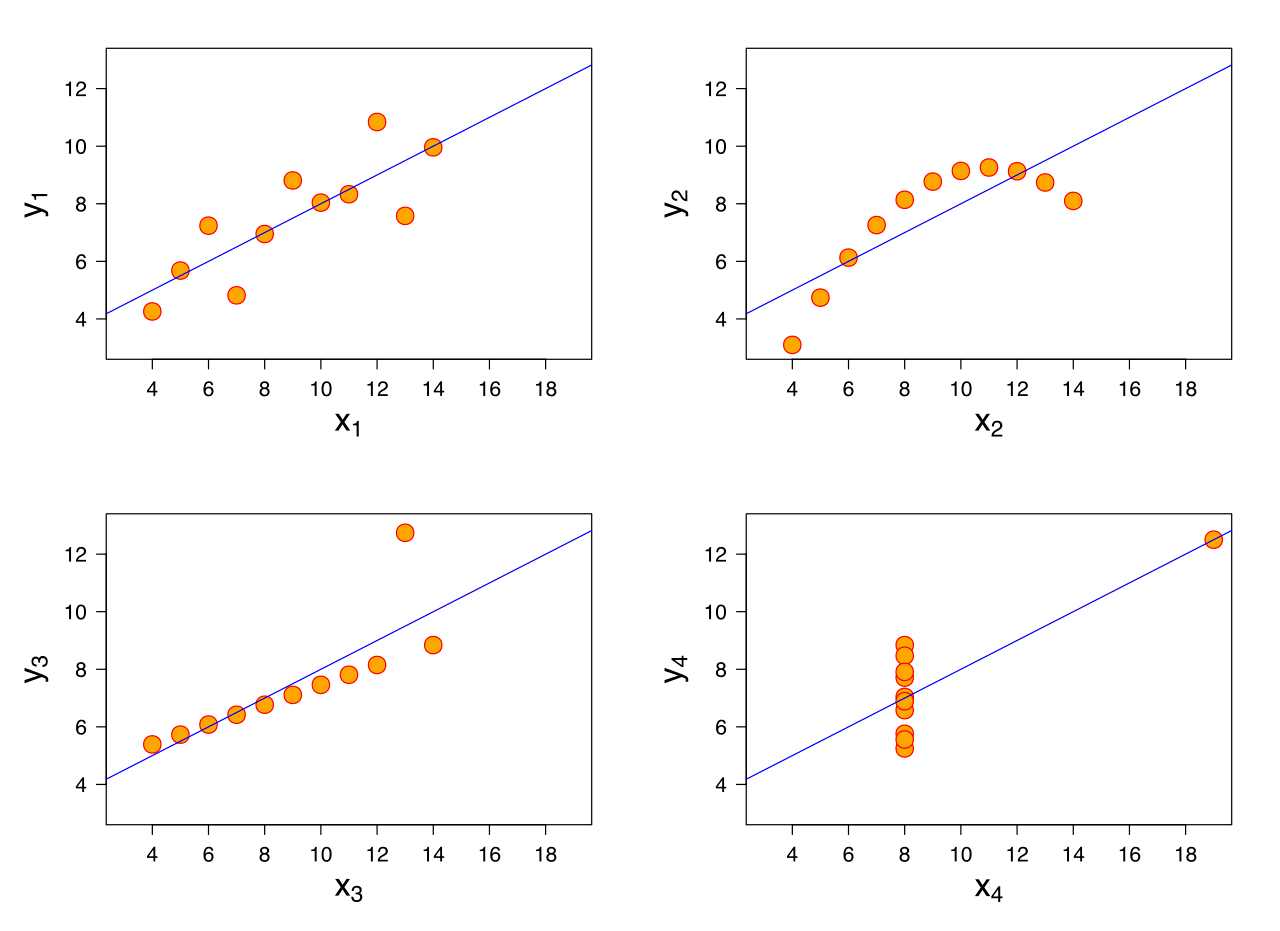

Dados, para os quatro conjunto de dados:

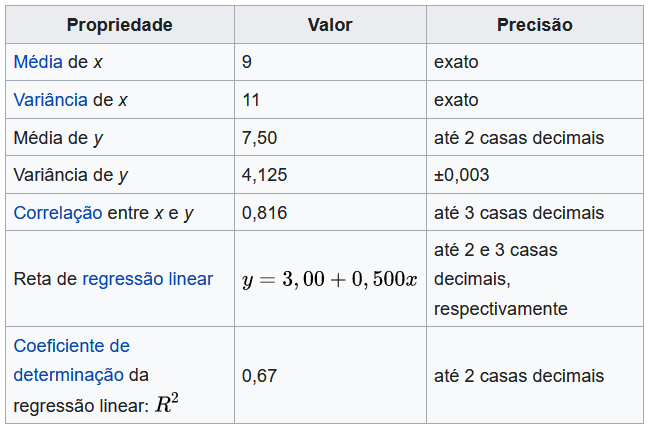

- O primeiro gráfico de dispersão (no canto superior esquerdo) aparenta ser uma simples relação linear, correspondendo a duas variáveis correlacionadas em que y poderia ser modelado como uma gaussiana com uma média linearmente dependente de x.
- O segudo gráfico (no canto superior direito) não mostra uma distribuição normal; enquanto a relação entre as duas variáveis é óbvia, ela não é linear, e o coeficiente de correlação de Pearson não é relevante. Uma regressão mais geral e o coeficiente de determinação correspondente seria mais apropriada.
- No terceiro gráfico (no canto inferior esquerdo), a distribuição é linear, mas deveria ter uma reta de regressão diferente (uma regressão robusta teria sido mais apropriada). A regressão calculada está deslocada por pelo único outlier que exerce influência suficiente para reduzir o coeficiente de correlação de 1 para 0.816.
- Finalmente, o quarto gráfico (no canto inferior direito) mostra um exemplo em que um ponto de grande alavanca é suficiente para produzir um grande coeficiente de correlação mas, embora outros pontos de dados não indiquem qualquer relação entre as variáveis.

O quarteto ainda é usado frequentemente para ilustrar a importância de visualizar um conjunto de dados graficamente antes de iniciar a análise de acordo com um tipo de relação particular, e a inadequação de propriedades estatísticas básicas para descrever conjuntos de dados realísticos.
https://pt.wikipedia.org/wiki/Quarteto_de_Anscombe

Vamos analisar a EDA de um dos primeiros colocados da competição de notas do ENEM: https://www.kaggle.com/sogeking/ml-olympiad-quality-education-eda-modelagem

Baseado nos dataset de:
https://www.kaggle.com/c/qualityeducation/data?select=train.csv

# Análise de Correlações

Associação entre as variáveis, linear ou não linear, é a correção. Veja que isso não é o mesmo de relação de causa x consequência.

A correlação apenas infere a relação entre duas variáveis, mesmo que isso signifique que ambas refletem uma interferência de outra variável independente. Exemplo: a altura dos pais é relacionada com a altura dos filhos. Entretanto, não podemos creditar a altura dos filhos unicamente à hereditariedade, ou então todos os filhos teriam a mesma altura. Muitos outros fatores, como o epigenética, nutrição, IMC... devem ser levados em conta.


1. Coeficiente de correlação de Pearson:

Mede a força de uma correlação linear. Esta correlação desenha uma linha entre dados de duas variáveis. A correlação de Pearson mostra quão longe os dados estão desta linha. Não é necessário que sejam utilizados dados da mesma categoria, nem que tenham a mesma unidade, pois a correlação é um dado adimensional. Eles precisam ser dados numéricos.

Ela trata todos os dados da mesma forma:



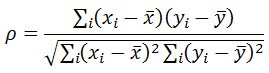

em que $x_{i}$, $x_{i}$, são as variável, $\bar{x}$, $\bar{y}$, são as médias.
Propriedades:

  Sempre estará entre [-1,1].
  Independe da escala ou unidade das variáveis.
   r = 1 (correlação perfeitamente positiva), r =-1 (correlação perfeitamente negativa)
   r = 0 (sem correlação)

  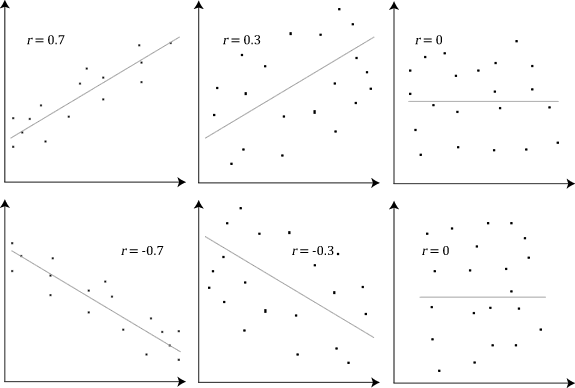

  2. Coeficiente de correlação de Spearman:

O coeficiente de correlação de Spearman é uma medida não paramétrica da força e direção da associação que existe entre duas variáveis ​​medidas em pelo menos uma escala ordinal.

Fórmula do coeficiente de correlação de Spearman

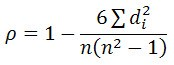


em que n = número total de observações, $d_{i}$ = ($x_{i}$-$y_{i}$) em que $x_{i}$ e $y_{i}$ são as observações

A correlação de Spearman determina a força e a direção da relação monotônica entre duas variáveis, em vez da força e direção da relação linear entre suas duas variáveis, que é o que a correlação de Pearson determina.

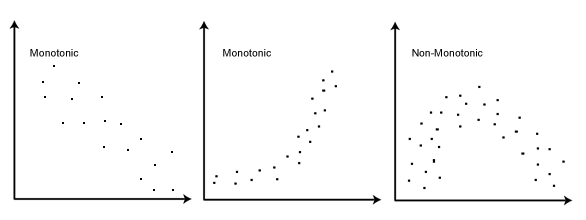




https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

Vocês acreditam que devemos usar para treinar a nossa máquina dados com alta correlação, ou baixa?
Quais erros podem advir de cada caso?

E quando analisamos correlação entrada x entrada ao invés de entrada x saída ou saída x saída ?

## Respostas


1. Correlação Entrada vs Saída (features vs target)
- **Alta correlação entre entrada e saída**: Quando há uma alta correlação entre uma entrada e a saída, isso pode ser positivo, pois o modelo consegue identificar padrões claros e previsíveis. Contudo, se a correlação for excessivamente alta, há o risco de overfitting, onde o modelo memoriza os dados de treinamento em vez de generalizar para novos dados.

- **Baixa correlação entre entrada e saída**: Uma baixa correlação pode indicar que a entrada não é muito útil para prever a saída. Isso pode resultar em um modelo que não consegue aprender padrões claros e, portanto, comete mais erros. Aqui, o modelo tende a underfitting, ou seja, não aprende bem nem mesmo os dados de treinamento.

2. Correlação entre Entradas (features vs features)

- **Alta correlação entre entradas**: Quando as variáveis de entrada são altamente correlacionadas entre si, isso pode criar redundância no modelo. Esse fenômeno é chamado de multicolinearidade, que pode prejudicar o desempenho do modelo, especialmente em algoritmos como regressão linear. Modelos podem ter dificuldade em distinguir a importância de cada variável correlacionada, o que pode levar a resultados instáveis ou coeficientes mal interpretados.

- **Baixa correlação entre entradas**: Quando as variáveis de entrada têm baixa correlação entre si, geralmente é desejável, pois indica que elas trazem informações complementares, sem redundância. Isso facilita para o modelo aprender padrões distintos e pode melhorar sua capacidade de generalização.

3. Erros associados
- **Com alta correlação entre entradas e saída**:
  * Overfitting: O modelo pode se ajustar demais aos dados de treinamento e performar mal em dados novos.
  * Dependência excessiva de uma feature: O modelo pode se tornar dependente de poucas variáveis e ser menos robusto.

- **Com baixa correlação entre entradas e saída**:
  * Underfitting: O modelo não captura bem os padrões nos dados, resultando em baixa acurácia tanto no treinamento quanto na validação.

- **Com alta correlação entre entradas**:
  * Multicolinearidade: Dificuldade em interpretar os pesos das variáveis, instabilidade nos coeficientes e pior desempenho em modelos lineares.

#Seleção de Features - passo a passo estruturado

Modelos com muitas features ficam muito complexos de se entender e explicar. Fazemos EDA e já pré-selecionamos todas as features mais pertinentes. Agora vamos ver uma forma estruturada de selecionar features para o nosso modelo:

##Método "All-In"

Usa todas as features disponíveis. É realizado quando se tem entendimento do dataset, e quando uma boa EDA foi realizada. Pode ser otimizado.

##Método Backward Elimination (Eliminação Regressiva)

Começa com todas as features e, a cada iteração, remove a feature que menos contribui para o desempenho do modelo, até que a remoção adicional degrade o desempenho.

Passo 1. Selecione o seu SL (threshold para o seu valor de p - significância estatística - normalmente 5%);

Passo 2. Realize o fit do seu modelo completo com todas as features;

Passo 3. Se o maior valor de p for maior que SL, considere a feature que gera esse maior valor de p. Se não, finalize o modelo;

Passo 4. Remova a feature com o maior valor de p;

Passo 5. Fit do modelo reduzido;

Passo 6 -> Repita o loop passos 3-4-5 até que entre no se não do passo 3.

##Método Forward Selection (Seleção Progressiva)

Começa sem features e, a cada iteração, adiciona a feature que mais melhora a performance do modelo até que nenhuma melhoria significativa ocorra.

Passo 1. Selecione o limite de SL;

Passo 2. Fit de todos os modelos de regressão linear simples - selecione o modelo com menor p;

Passo 3. Use o modelo de menor p do passo anterior e adicione uma feature a mais, com todas as features restantes. Ache o modelo de menor p.

Passo 4 -> Repita o passo 3 até que o menor valor de p seja maior que SL;

Passo 5. Mantenha o modelo obtido antes de p exceder o valor de SL.

##Bidirectional

Passo 1. Selecione SL para uma variável entrar no modelo e sair do modelo (podem ser valores diferentes);

Passo 2. Faça o forward selection para uma variável a mais (se primeira iteração, para uma variável);

Passo 3. Faça todos os passos do backward elimination;

Passo 4-> Repita o loop passos 2 e 3 até que não seja possível adicionar ou remover mais variáveis (devido aos limites de p);

Passo 5. Selecione o último modelo em que p menor que SL em todos os casos.

##Score Comparison

Passo 1. Selecione seu método de validação;

Passo 2. Fit de todos os modelos possíveis (2^N -1 combinações);

Passo 3. Selecione o modelo com melhor score.